# FTL099 - Inteligência Artificial Aplicada  
Aluno: Nycksandro Lima dos Santos  
Matrícula: 22351228  

# Trabalho 03 - Árvores de Decisão

Nesse trabalho sobre árvores de decisão pede-se que, utilizando random forest
preveja-se a máxima temperatura na cidade de *Seatle*, usando informações passadas do
clima. Estão disponíveis 6 anos de dados. Cinco variáveis distintas devem ser usadas para
a predição: year, ws_1, temp_2, temp_1, average. Essas variáveis são encontradas em
cada registro da tabela *temps_extended.xlsx*. Essa tabela, de onde extraímos os cinco
registros mostrados abaixo, contém outras variáveis além das cinco acima mencionadas.
A variável *actual* corresponde a temperatura máxima verificada no dia

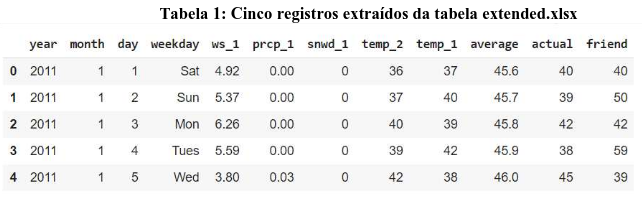

O significado das 5 variáveis selecionadas é descrito a seguir:

year – ano em que o registro ocorreu  
ws_1 – velocidade média do vento um dia antes  
temp_2 – temperatura máxima dois dias antes  
temp_1 – temperatura máxima um dia antes  
average – histórico de média de temperaturas máximas  

### **Instruções**

Avalie o desempenho de três modelos usando *random forest*. Você tem
os seguintes hiperparâmetros de procura utilizando a biblioteca do *scikit learn*.

Para cada modelo escolha um valor para cada parâmetro, dentre os valores mostrados. Por exemplo, um modelo poderia ser:
  
  ```
  model = RandomForestRegressor(bootstrap = True,
  n_`estimators=200,max_depth = 4, min_samples_leaf=4,
  min_samples_split=5)
  ```
* bootstrap:[True, False] $\longrightarrow$ o Esse parâmetro indica se vai ser usado ou não bootstrap para construir os conjuntos de treinamento.

* max_depth: Escolher [3, 4, 5, 10, 15, 20, 30, 40, 50, 60] $\longrightarrow$ o Esse parâmetro indica a máxima profundidade da árvore.

* min_samples_leaf: [1, 2, 4] $\longrightarrow$ Esse parâmetro especifica o número mínimo de amostras necessárias para estar em um nó de folha. Um ponto de divisão em qualquer profundidade só será considerado se deixar pelo menos min_samples_leaf de amostras de treinamento em cada um dos ramos esquerdo e direito. Isso pode ter o efeito de suavizar o modelo, especialmente na regressão.

* min_samples_split: [2, 5, 10] $\longrightarrow$ Esse parâmetro especifica o número mínimo de amostras necessárias para dividir um nó interno.

* n_estimators: [200, 400, 600] $\longrightarrow$ O número de árvores na floresta.

Para esse experimento, divida o conjunto de dados inicial em 75% para treinamento e 25% para teste. Faça alguns experimentos em busca de um modelo que resulte numa maior precisão. Mostre o melhor modelo obtido em termos do erro absoluto médio e do erro quadrático médico no conjunto de teste. Para cada modelo, determine a importância das variáveis.

### **Importando bibliotecas**



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

### **Carregando dados**

In [ ]:
dados = pd.read_excel("temps_extended.xlsx") # Lendo a tabela contendo as temperatura
dados_limpo = dados.dropna()  # Limpando possíveis linhas com valores nulos
print(f"Número de Linhas: {len(dados_limpo)}")
print(f"Número de Colunas: {len(dados_limpo.columns)}")
print(f"Colunas da base de dados: {dados_limpo.columns}")

Número de Linhas: 2191
Número de Colunas: 12
Colunas da base de dados: Index(['year', 'month', 'day', 'weekday', 'ws_1', 'prcp_1', 'snwd_1', 'temp_2',
       'temp_1', 'average', 'actual', 'friend'],
      dtype='object')


In [ ]:
variaveis_p =['year', 'ws_1', 'temp_2', 'temp_1', 'average'] # Variavéis para predição

x = dados_limpo[variaveis_p].values # As 5 variaveis para predição
y = dados_limpo['actual'].values # Temperatura máxima do dia

### **Dividindo os dados em partições**

Divindo na proporção 75% para Treino e 25% para Teste

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x,y,train_size=0.75, test_size=0.25,random_state=33)

### **Construindo os modelos**

Serão construidos 3 modelos com parâmetros diferentes

* modelo1:
  * bootstrap=True
  * max_depth=5
  * min_samples_leaf=1
  * min_samples_split=2
  * n_estimator=200

* modelo2:
  * bootstrap=True
  * max_depth=40
  * min_samples_leaf=4
  * min_samples_split=10
  * n_estimator=400

* modelo3:
  * bootstrap=False
  * max_depth=20
  * min_samples_leaf=2
  * min_samples_split=5
  * n_estimator=600

In [ ]:
modelo1 = RandomForestClassifier(bootstrap=True, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200)
modelo2 = RandomForestClassifier(bootstrap=True, max_depth=40, min_samples_leaf=4, min_samples_split=10, n_estimators=400)
modelo3 = RandomForestClassifier(bootstrap=False, max_depth=20,min_samples_leaf=2, min_samples_split=5, n_estimators=600)

### **Treinando os modelos**

In [ ]:
modelo1.fit(x_treino, y_treino)
modelo2.fit(x_treino, y_treino)
modelo3.fit(x_treino, y_treino)

RandomForestClassifier(bootstrap=False, max_depth=20, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=600)

### **Avaliando os modelos**

In [ ]:
# Obtendo o y predito de cada modelo
y_predito_modelo1 = modelo1.predict(x_teste)
y_predito_modelo2 = modelo2.predict(x_teste)
y_predito_modelo3 = modelo3.predict(x_teste)

# Obtendo o erro absoluto médio de cada predição
erro_abs_medio1 = metrics.mean_absolute_error(y_teste, y_predito_modelo1)
erro_abs_medio2 = metrics.mean_absolute_error(y_teste, y_predito_modelo2)
erro_abs_medio3 = metrics.mean_absolute_error(y_teste, y_predito_modelo3)

# Obtendo o erro quadrático médio de cada predição
erro_quad_medio1 = metrics.mean_squared_error(y_teste, y_predito_modelo1)
erro_quad_medio2 = metrics.mean_squared_error(y_teste, y_predito_modelo2)
erro_quad_medio3 = metrics.mean_squared_error(y_teste, y_predito_modelo3)

In [ ]:
print(f"Modelo1: Erro Absoluto Médio = {erro_abs_medio1:.3f} e Erro quadrático médio {erro_quad_medio1:.3f}")

Modelo1: Erro Absoluto Médio = 4.151 e Erro quadrático médio 28.845


In [ ]:
print(f"Modelo2: Erro Absoluto Médio = {erro_abs_medio2:.3f} e Erro quadrático médio {erro_quad_medio2:.3f}")

Modelo2: Erro Absoluto Médio = 4.427 e Erro quadrático médio 34.131


In [ ]:
print(f"Modelo3: Erro Absoluto Médio = {erro_abs_medio3:.3f} e Erro quadrático médio {erro_quad_medio3:.3f}")

Modelo3: Erro Absoluto Médio = 4.697 e Erro quadrático médio 37.796


### **Importância das variáveis**


In [ ]:
importancia_variaveis_modelo1 = pd.Series(modelo1.feature_importances_,index=variaveis_p).sort_values(ascending=False)
importancia_variaveis_modelo2 = pd.Series(modelo2.feature_importances_,index=variaveis_p).sort_values(ascending=False)
importancia_variaveis_modelo3 = pd.Series(modelo3.feature_importances_,index=variaveis_p).sort_values(ascending=False)

In [ ]:
print(f"--- Importância das variáveis no modelo1 ---\n{importancia_variaveis_modelo1}")

--- Importância das variáveis no modelo1 ---
temp_1     0.370766
average    0.253582
temp_2     0.195627
ws_1       0.125226
year       0.054799
dtype: float64


In [ ]:
print(f"--- Importância das variáveis no modelo2 ---\n{importancia_variaveis_modelo2}")

--- Importância das variáveis no modelo2 ---
temp_1     0.249353
average    0.246627
ws_1       0.195813
temp_2     0.192770
year       0.115438
dtype: float64


In [ ]:
print(f"--- Importância das variáveis no modelo3 ---\n{importancia_variaveis_modelo3}")

--- Importância das variáveis no modelo3 ---
average    0.250950
temp_1     0.215843
ws_1       0.215093
temp_2     0.189921
year       0.128193
dtype: float64
